In [1]:
import numpy as np
import pandas as pd
from plotnine import *

In this notebook, for each parameter (feature) in SWAN-SF, we visualize the
dependence of the distribution of the parameter on the heliocentric angle.

In [2]:
all_ars_df = pd.read_parquet("all_ars_df.parquet")
PARAMS = [
    "ABSNJZH", "EPSX", "EPSY", "EPSZ", "MEANALP", "MEANGAM", "MEANGBH",
    "MEANGBT", "MEANGBZ", "MEANJZD", "MEANJZH", "MEANPOT", "MEANSHR", "R_VALUE",
    "SAVNCPP", "SHRGT45", "TOTBSQ", "TOTFX", "TOTFY", "TOTFZ", "TOTPOT",
    "TOTUSJH", "TOTUSJZ", "USFLUX"
]
all_ars_df.head()

,partition,ar_num,Timestamp,TOTUSJH,TOTBSQ,TOTPOT,TOTUSJZ,ABSNJZH,SAVNCPP,USFLUX,...,EPSX,R_VALUE,CRVAL1,CRLN_OBS,CRLT_OBS,CRVAL2,HC_ANGLE,SPEI,QUALITY,IS_TMFI
0,5,6966,2017-03-15 23:00:00+00:00,5.706510,5.630422e+07,3.651980e+20,1.377949e+11,0.501566,3.870333e+10,1.337773e+20,...,-0.206471,0.0,188.465393,229.610748,-7.161022,13.2617,45.113125,True,0.0,True
1,5,6966,2017-03-15 23:12:00+00:00,6.119197,6.079127e+07,4.245861e+20,1.558232e+11,0.351083,1.537080e+10,1.441639e+20,...,-0.228652,0.0,188.467682,229.500534,-7.161000,13.2617,45.015232,True,0.0,True
2,5,6966,2017-03-15 23:24:00+00:00,10.626178,9.368851e+07,7.356111e+20,2.749181e+11,0.433292,5.376569e+10,2.324659e+20,...,-0.263019,0.0,188.470032,229.390335,-7.160944,13.2617,44.917339,True,0.0,True
3,5,6966,2017-03-15 23:36:00+00:00,16.168055,1.399006e+08,1.067302e+21,4.146579e+11,0.304617,2.239097e+10,3.395013e+20,...,-0.243114,0.0,188.472366,229.280167,-7.160855,13.2617,44.819529,True,0.0,True
4,5,6966,2017-03-15 23:48:00+00:00,16.154519,1.447615e+08,1.049642e+21,4.007746e+11,0.500570,8.780494e+10,3.569914e+20,...,-0.241811,0.0,188.474716,229.170013,-7.160730,13.2617,44.721758,True,0.0,True


The histogram below shows that most records have a moderate heliocentric angle.
Few records have a heliocentric angle close to zero. Given the patterns in [the
butterfly diagram](https://commons.wikimedia.org/w/index.php?title=File:Sun_-_btly_-_2023.png&oldid=825479341),
this makes sense.

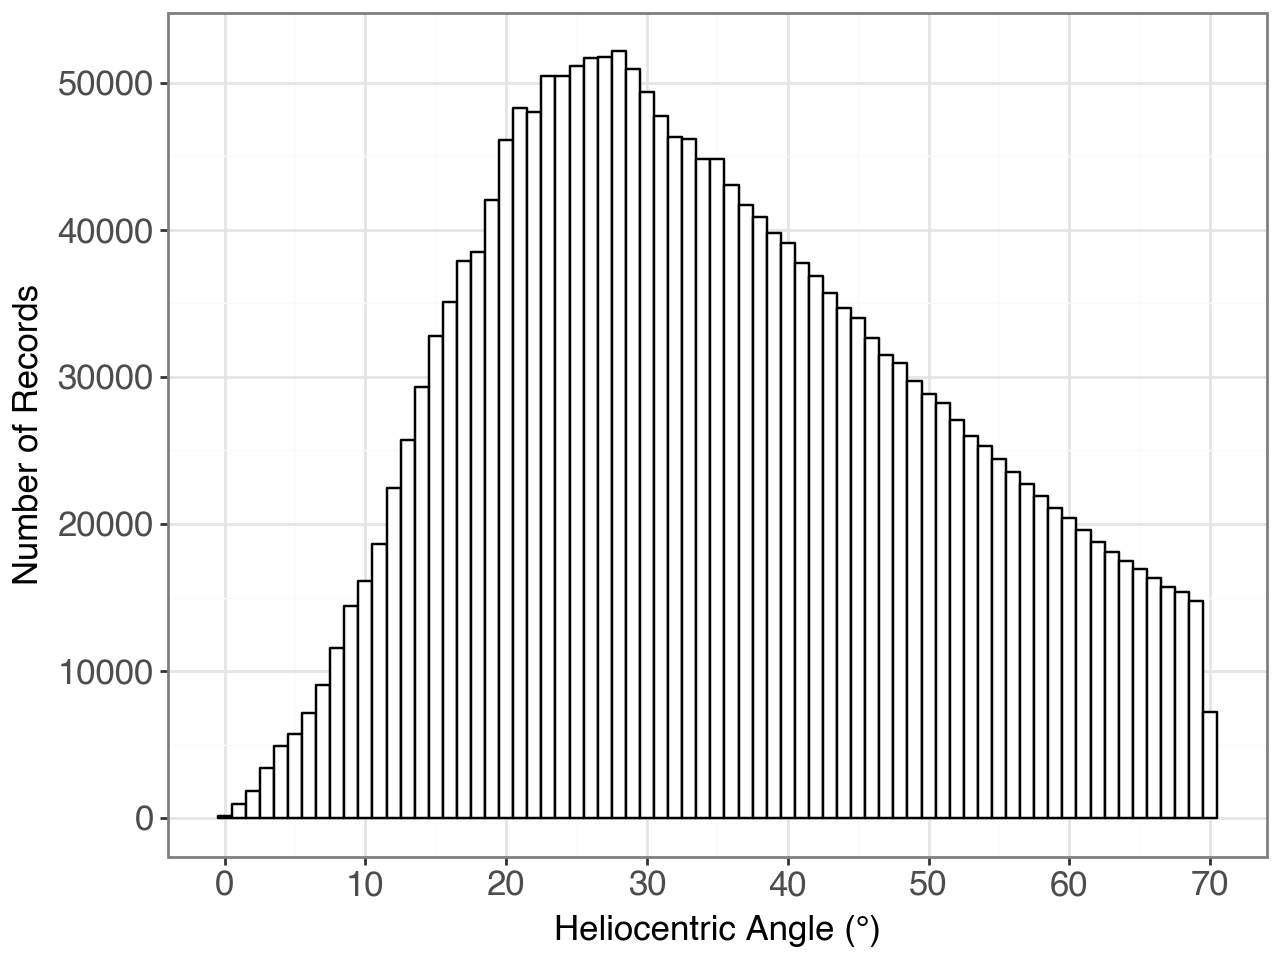

In [3]:
(
    ggplot(all_ars_df.query("IS_TMFI"), aes(x="HC_ANGLE")) +
    geom_histogram(binwidth=1, fill="white", color="black") +
    scale_x_continuous(breaks=np.arange(8) * 10) +
    labs(x="Heliocentric Angle (°)", y="Number of Records") +
    theme_bw() +
    theme(text=element_text(size=12.5))
)

The functions below will be used to make the visualizations.

In [4]:
def _make_y_label(x: float) -> str:
    if 0 < abs(x) < 1e-4 or abs(x) > 1e4:
        label = f"{x:.2e}"
    else:
        label = f"{x:,.2f}"
    return label

def plot_param_cond_dists(
        param: str,
        *,
        min_quantile_level: float = 0.0,
        max_quantile_level: float = 1.0,
        bin_width: int = 5,
        x_axis_rotation_angle: float = 0.0,
        units: str = ""
) -> ggplot:
    """
    Plot a parameter's conditional distributions for heliocentric angle bins
    """
    if param not in PARAMS:
        raise ValueError(f"`param` ({param}) isn't in `PARAMS` ({PARAMS}).")

    if min_quantile_level < 0 or min_quantile_level > 1:
        raise ValueError(
            f"`min_quantile_level` ({min_quantile_level}) isn't in [0, 1]."
        )
    if max_quantile_level < 0 or max_quantile_level > 1:
        raise ValueError(
            f"`max_quantile_level` ({max_quantile_level}) isn't in [0, 1]."
        )
    if min_quantile_level > max_quantile_level:
        raise ValueError(
            f"`min_quantile_level` ({min_quantile_level}) > "
            f"`max_quantile_level` ({max_quantile_level})."
        )

    if not isinstance(bin_width, int):
        raise TypeError(f"`bin_width` ({bin_width}) must be an integer.")
    if bin_width < 1:
        raise ValueError(f"`bin_width` ({bin_width}) < 1.")

    plot_df = all_ars_df.query("IS_TMFI")[["HC_ANGLE", param]].copy()

    quantiles = np.quantile(
        plot_df[param].dropna(),
        [min_quantile_level, max_quantile_level],
        method="inverted_cdf"
    )
    plot_df = plot_df[
        (plot_df[param] >= quantiles[0]) & (plot_df[param] <= quantiles[1])
    ]

    # Round to the nearest multiple of bin_width
    plot_df["HC_ANGLE"] = pd.Categorical(
        (bin_width * (plot_df["HC_ANGLE"] / bin_width).round()).astype(int)
    )
    counts = plot_df.value_counts("HC_ANGLE").reset_index(drop=False)
    plot_df = plot_df.merge(counts, on="HC_ANGLE")

    divisor = plot_df[param].abs().max()
    plot_df[param] /= divisor # plotnine can have trouble plotting big values

    y_breaks = np.linspace(plot_df[param].min(), plot_df[param].max(), num=4)
    y_labels = [_make_y_label(brk * divisor) for brk in y_breaks]
    color_breaks = [plot_df["count"].min(), plot_df["count"].max()]
    color_labels = [f"{brk:,}" for brk in color_breaks]

    units = f" ({units})" if units != "" else ""

    if min_quantile_level > 0 or max_quantile_level < 1:
        quantile_level_strs = [
            f"{q}"
            for q in [min_quantile_level, max_quantile_level] if 0 < q < 1
        ]
        caption=(
            f"{param} values beyond "
            f"{', '.join(quantile_level_strs)} quantile(s) "
            "were dropped."
        )
    else:
        caption = None

    plot = (
        ggplot(plot_df, aes(x="HC_ANGLE", y=param, color="count")) +
        geom_boxplot() +
        scale_y_continuous(breaks=y_breaks, labels=y_labels) +
        scale_color_gradient(
            low="lightgray", high="black",
            breaks=color_breaks, labels=color_labels
        ) +
        labs(
            x=f"Heliocentric Angle Rounded to Nearest Multiple of {bin_width}°",
            y=f"{param}{units}",
            color="Number of Records",
            caption=caption
        ) +
        theme_bw() +
        theme(
            axis_text_x=element_text(rotation=x_axis_rotation_angle),
            legend_position="bottom"
        )
    )

    return plot

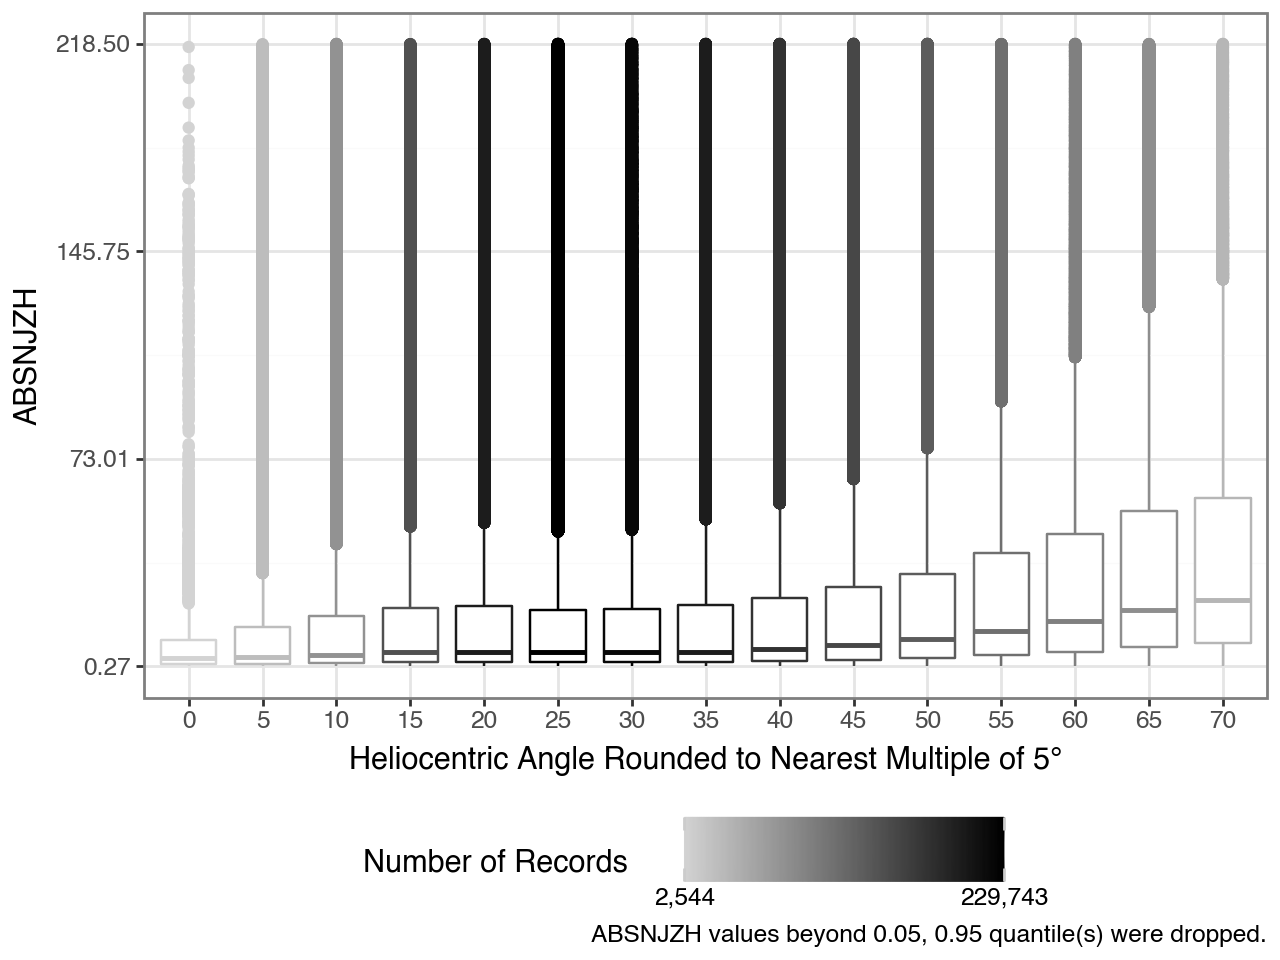

In [5]:
plot_param_cond_dists(
    "ABSNJZH", min_quantile_level=0.05, max_quantile_level=0.95
)

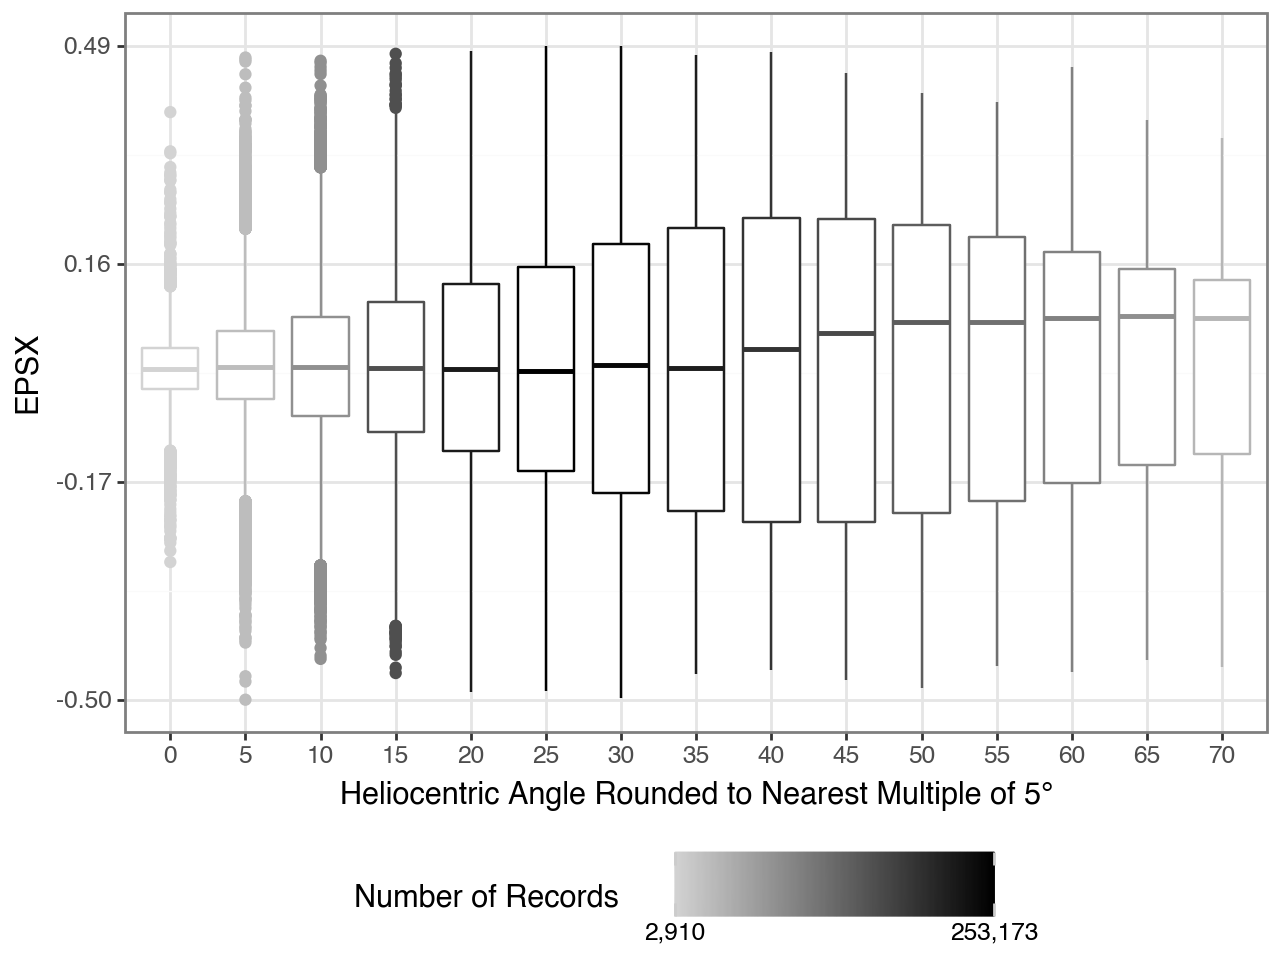

In [6]:
plot_param_cond_dists("EPSX")

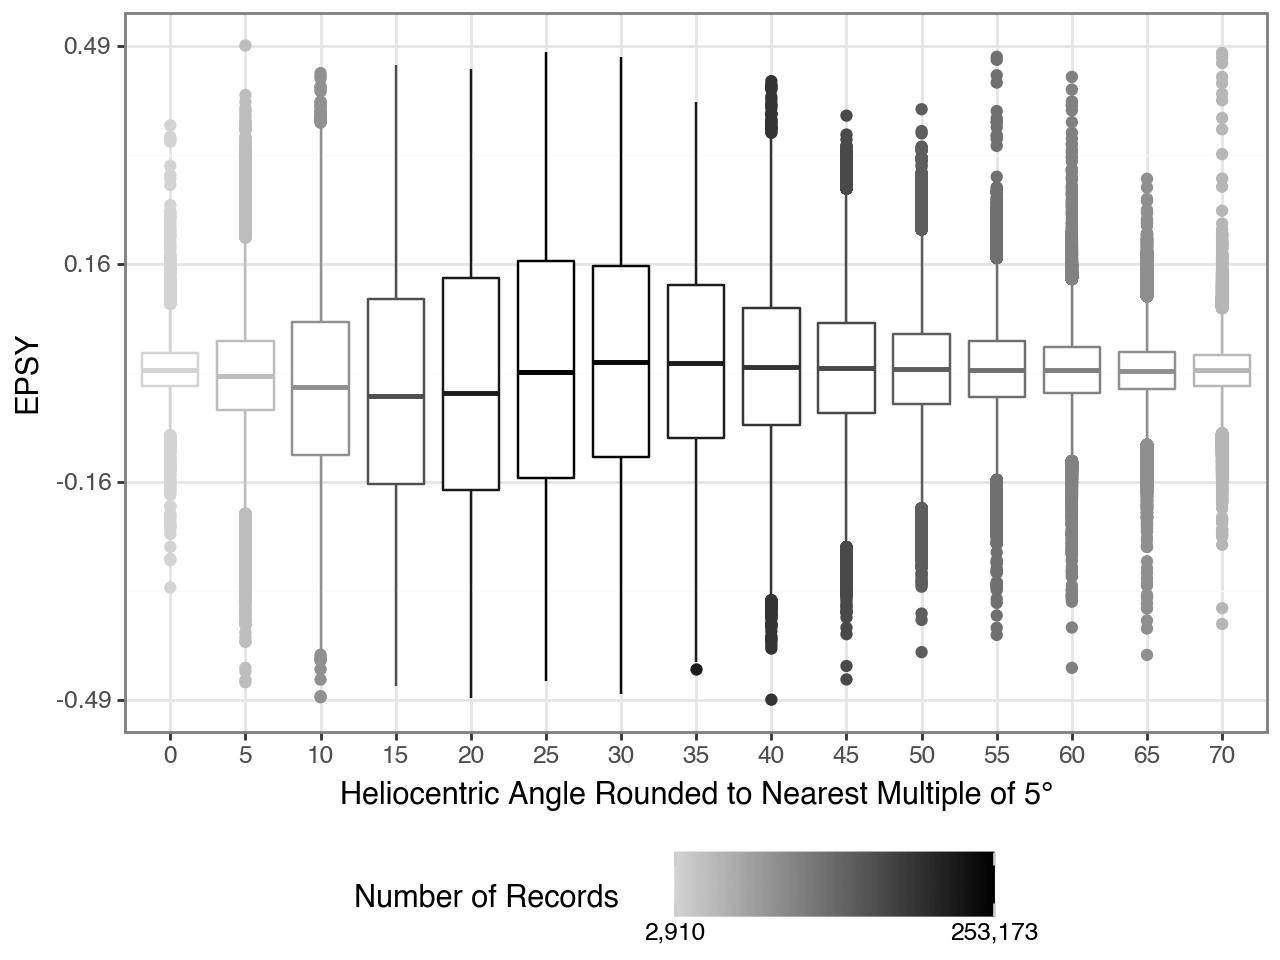

In [7]:
plot_param_cond_dists("EPSY")

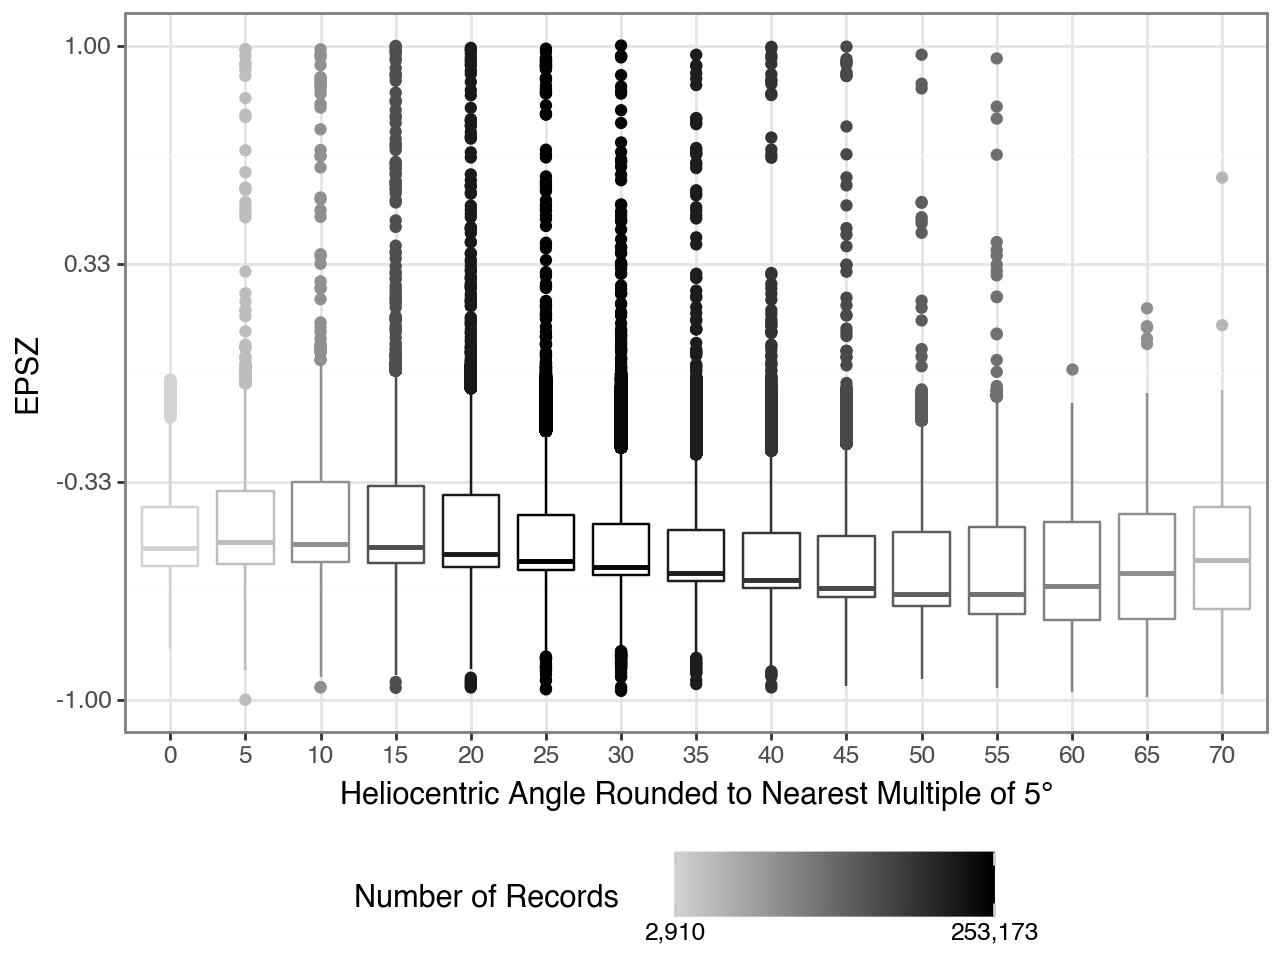

In [8]:
plot_param_cond_dists("EPSZ")

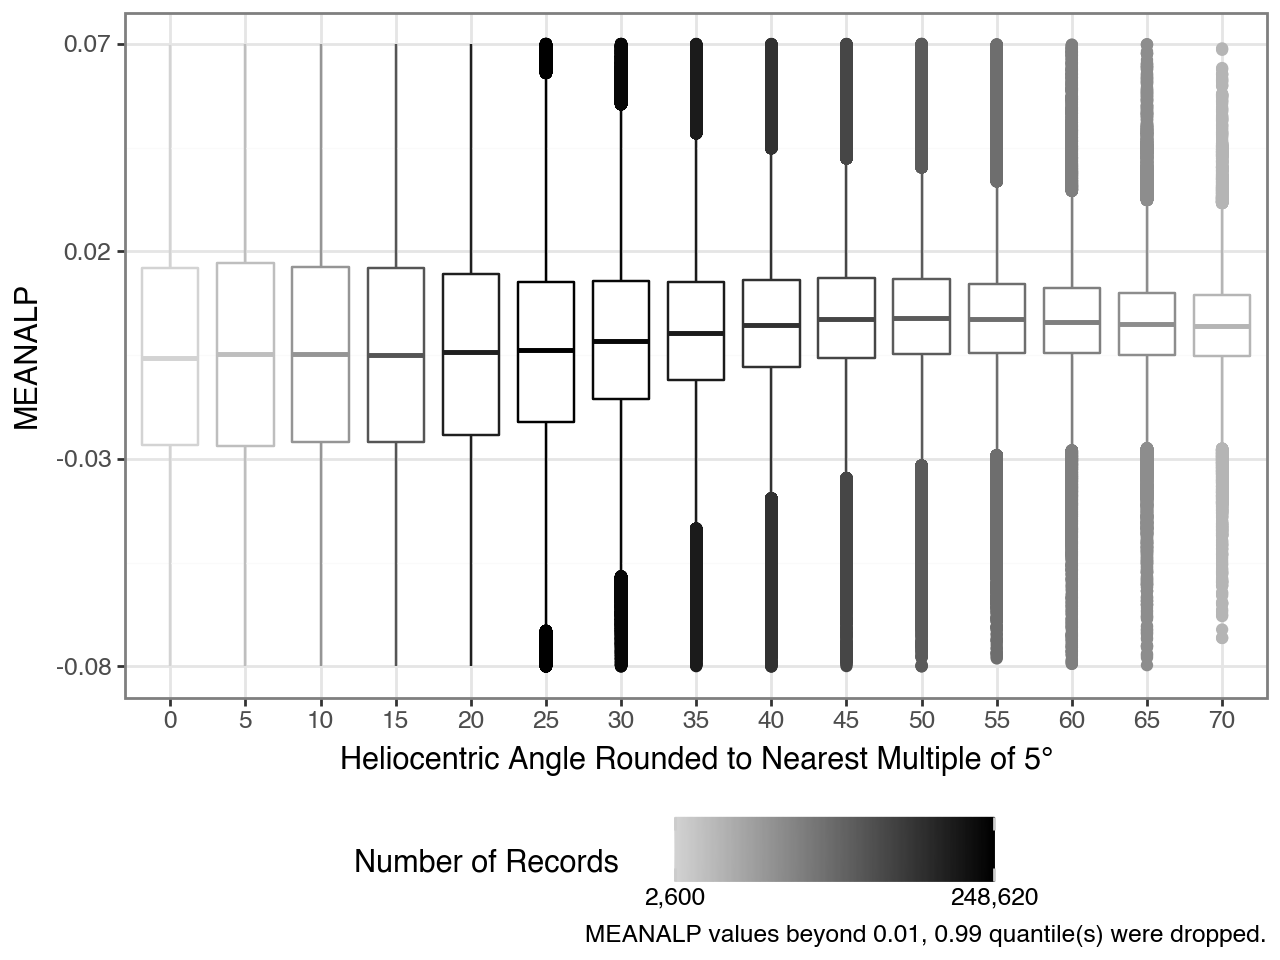

In [9]:
plot_param_cond_dists(
    "MEANALP", min_quantile_level=0.01, max_quantile_level=0.99
)

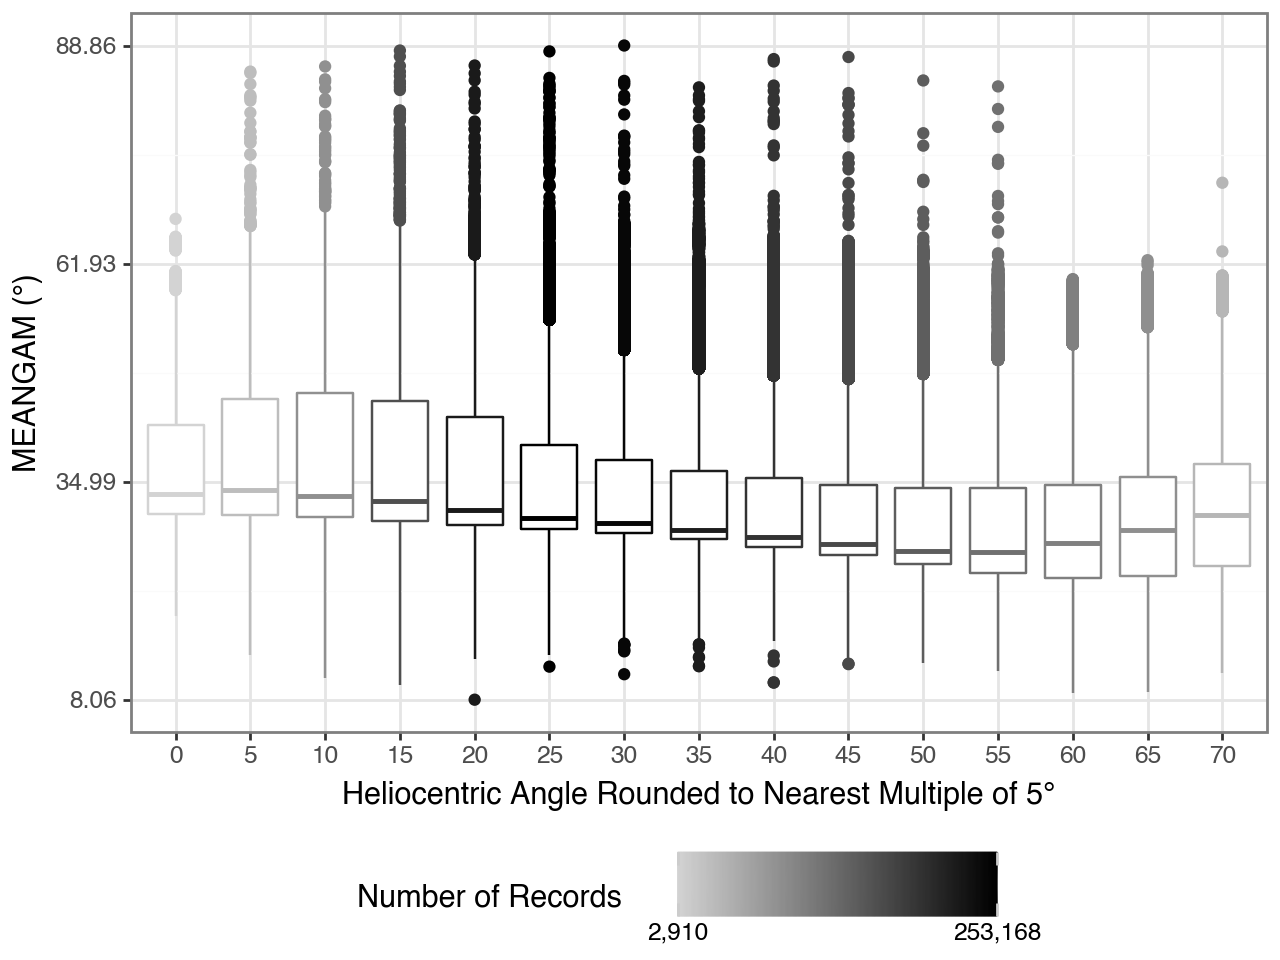

In [10]:
plot_param_cond_dists("MEANGAM", units="°")

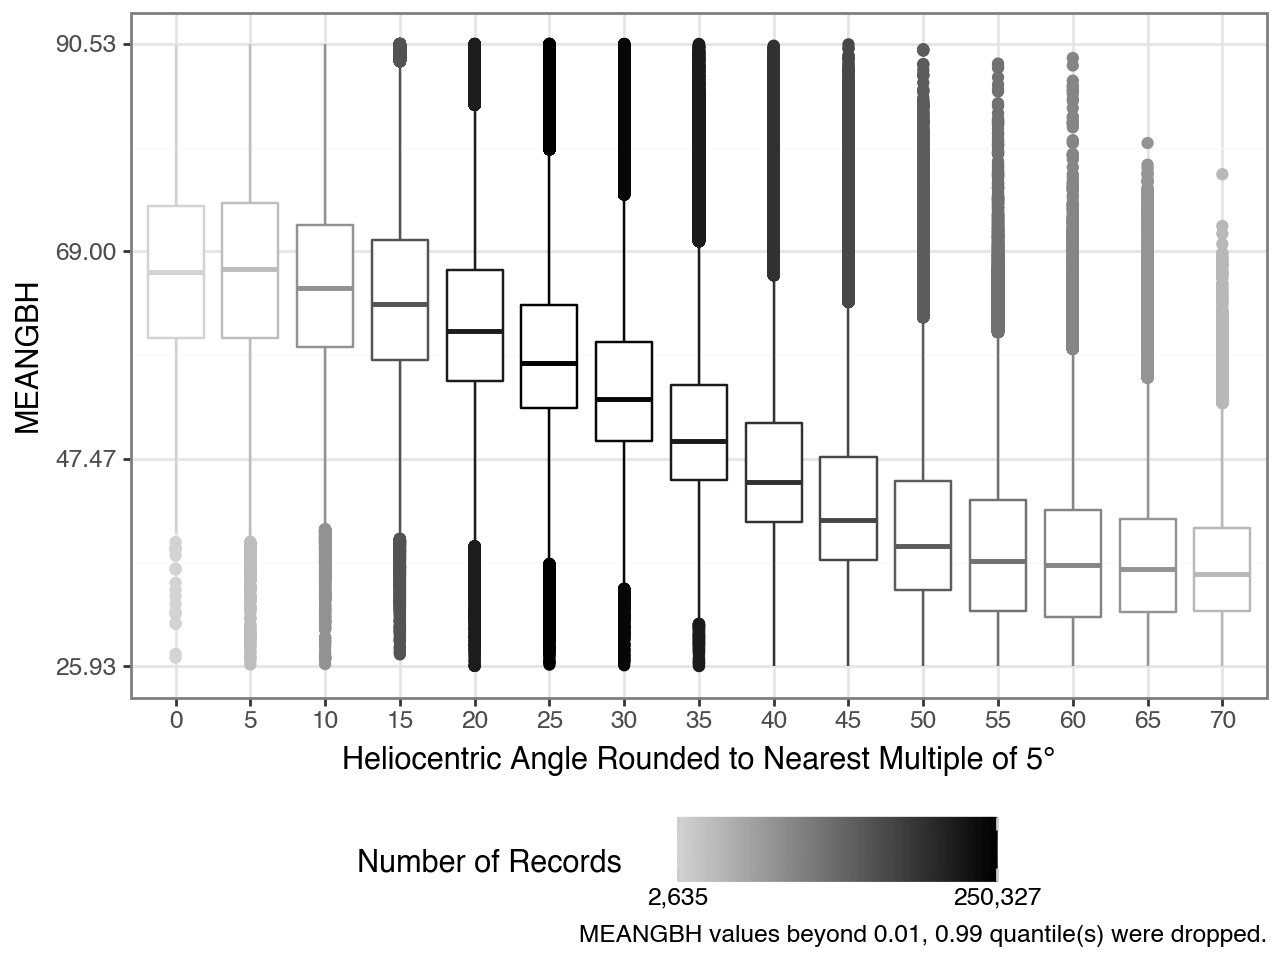

In [11]:
plot_param_cond_dists(
    "MEANGBH", min_quantile_level=0.01, max_quantile_level=0.99
)

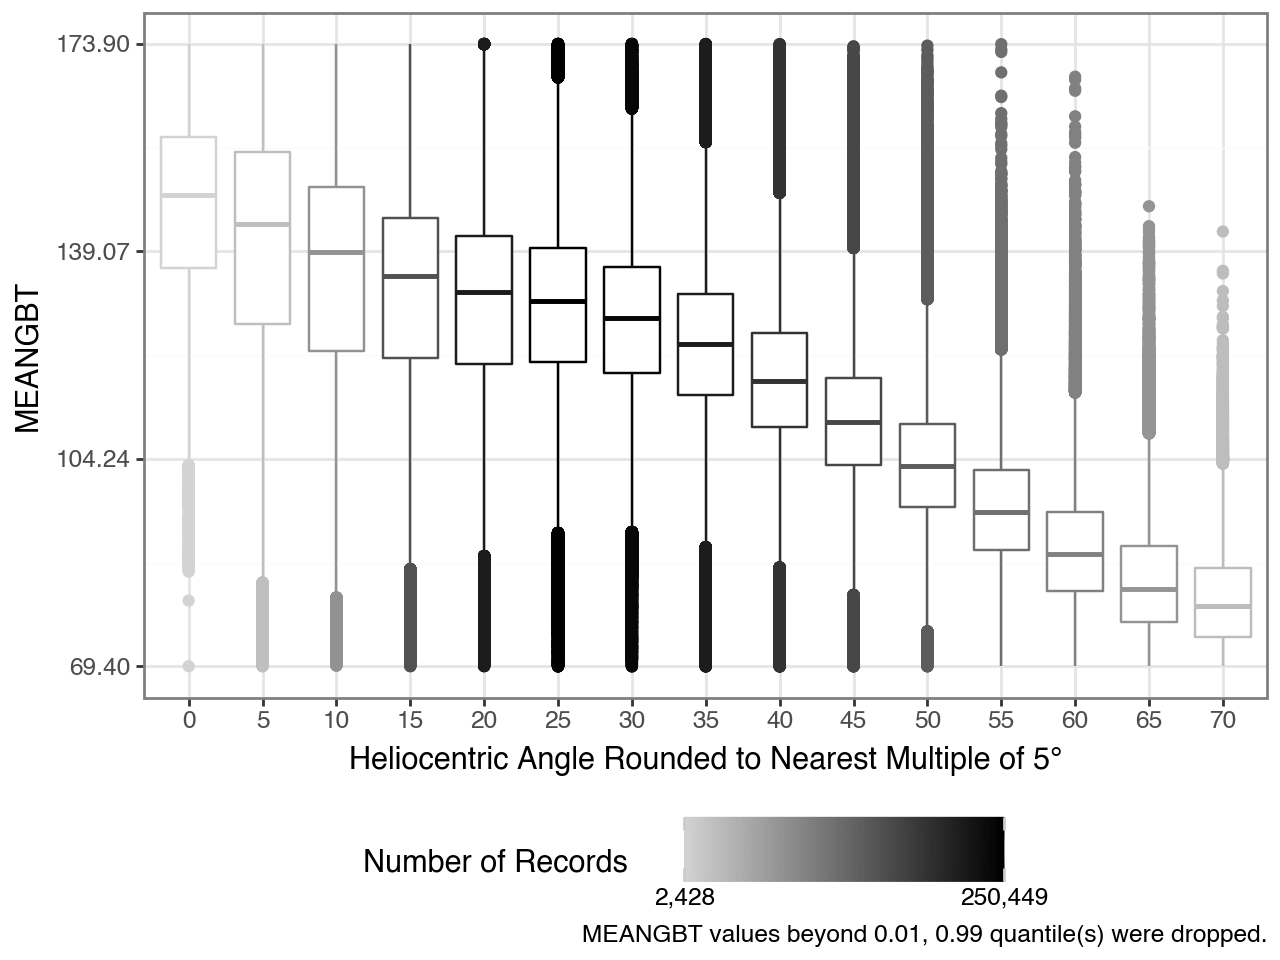

In [12]:
plot_param_cond_dists(
    "MEANGBT", min_quantile_level=0.01, max_quantile_level=0.99
)

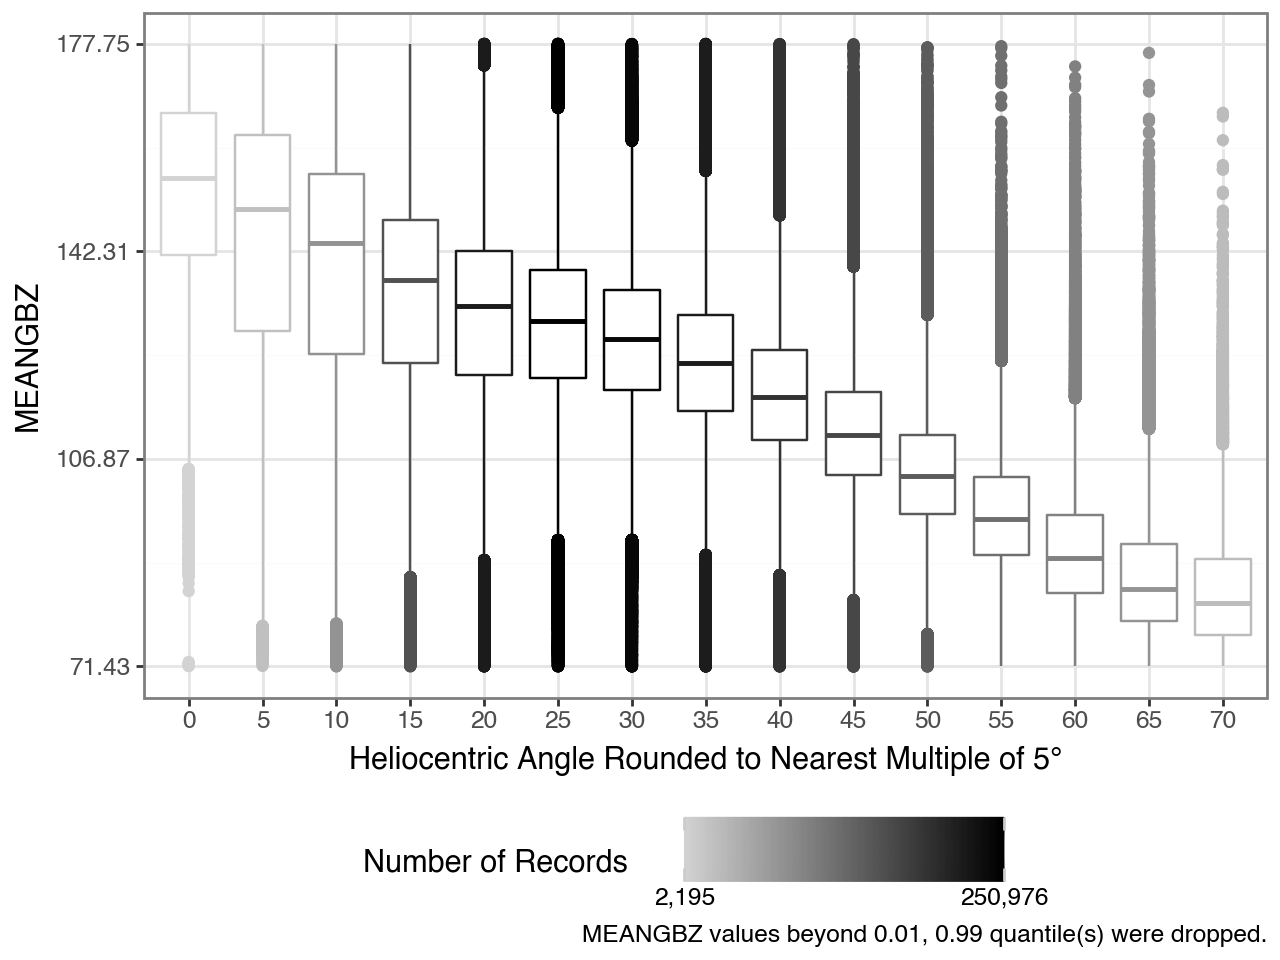

In [13]:
plot_param_cond_dists(
    "MEANGBZ", min_quantile_level=0.01, max_quantile_level=0.99
)

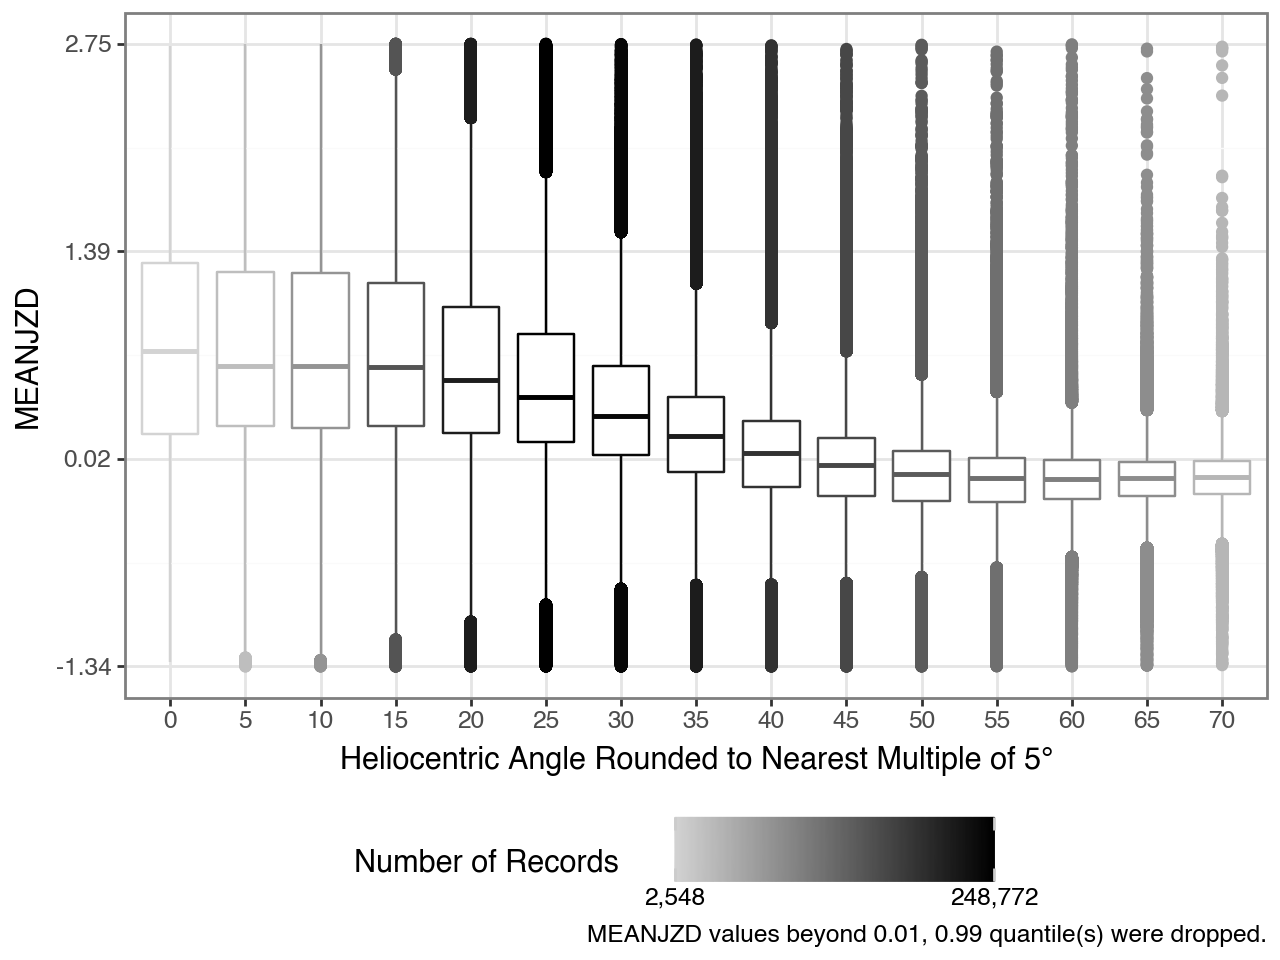

In [14]:
plot_param_cond_dists(
    "MEANJZD", min_quantile_level=0.01, max_quantile_level=0.99
)

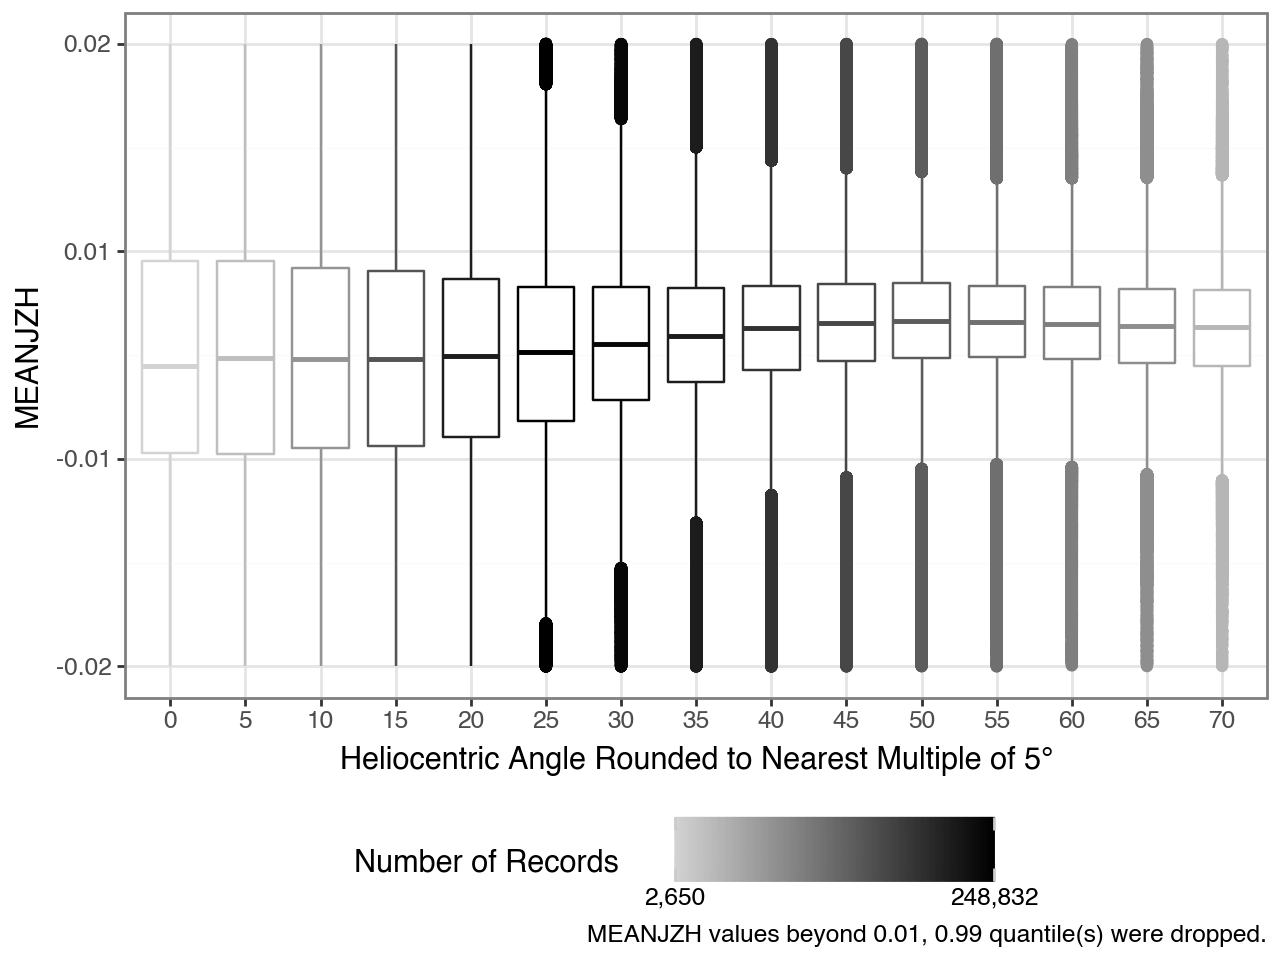

In [15]:
plot_param_cond_dists(
    "MEANJZH", min_quantile_level=0.01, max_quantile_level=0.99
)

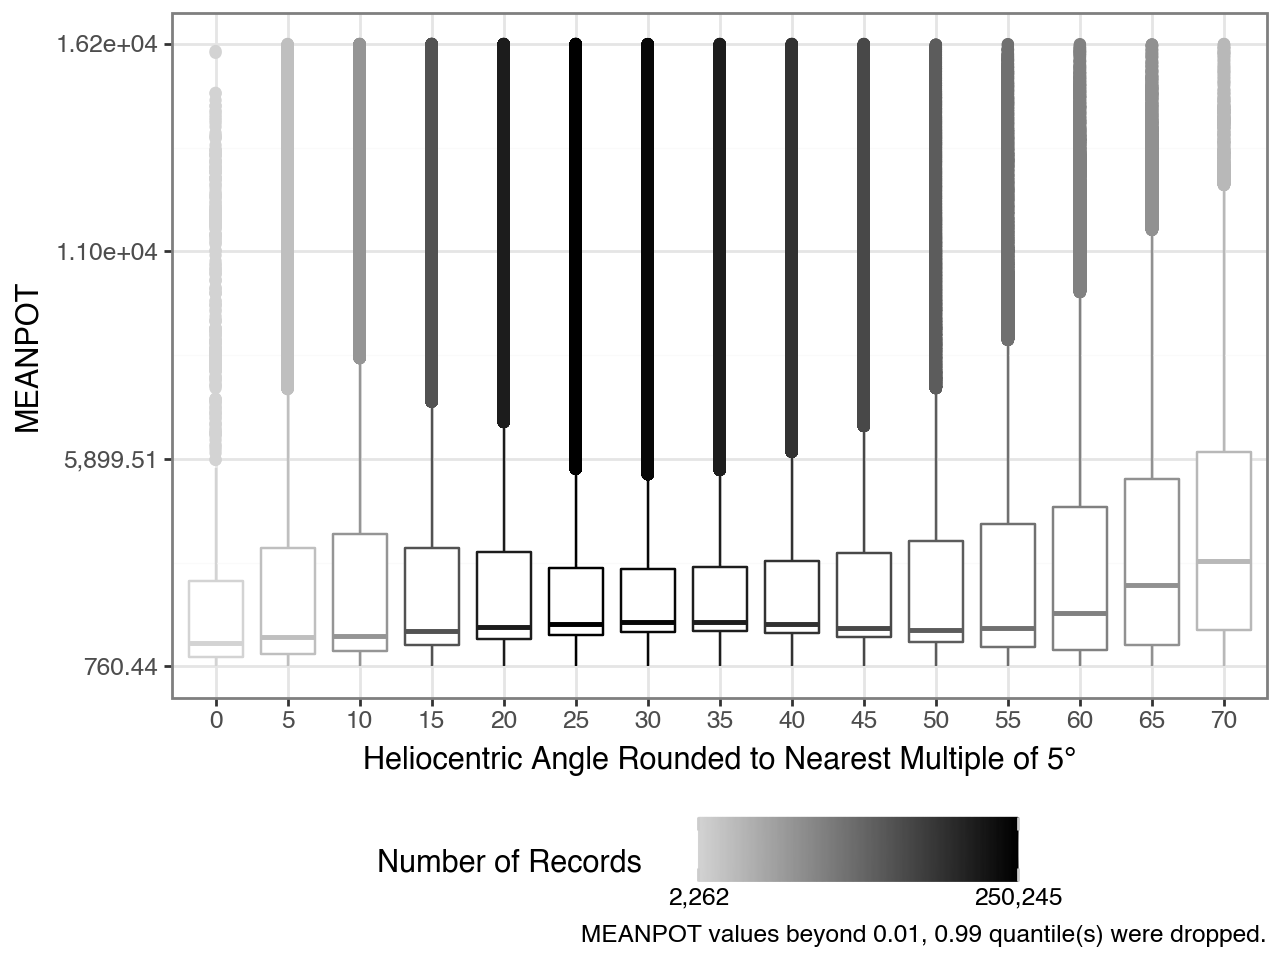

In [16]:
plot_param_cond_dists(
    "MEANPOT", min_quantile_level=0.01, max_quantile_level=0.99
)

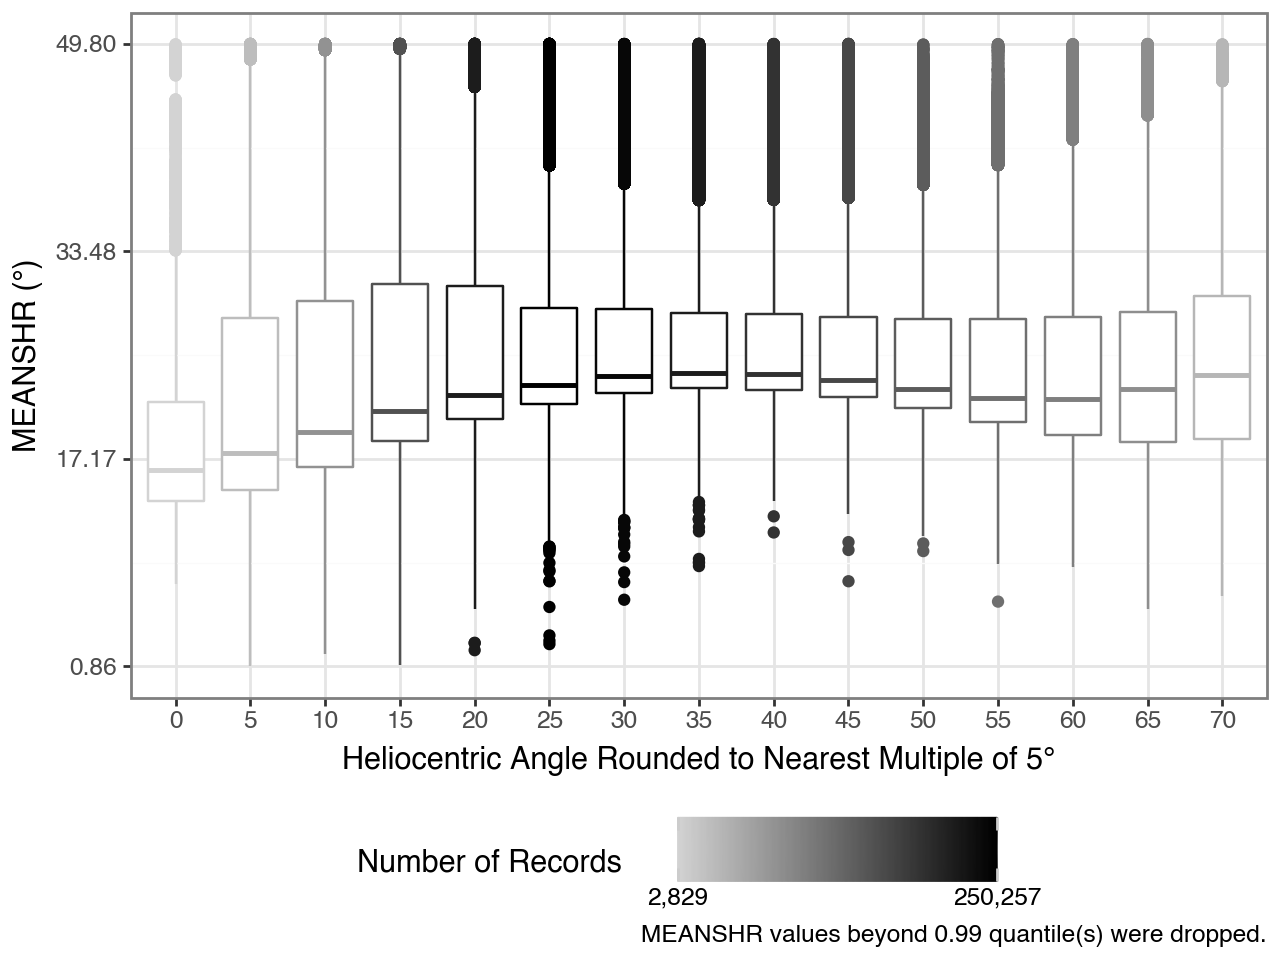

In [17]:
plot_param_cond_dists("MEANSHR", max_quantile_level=0.99, units="°")

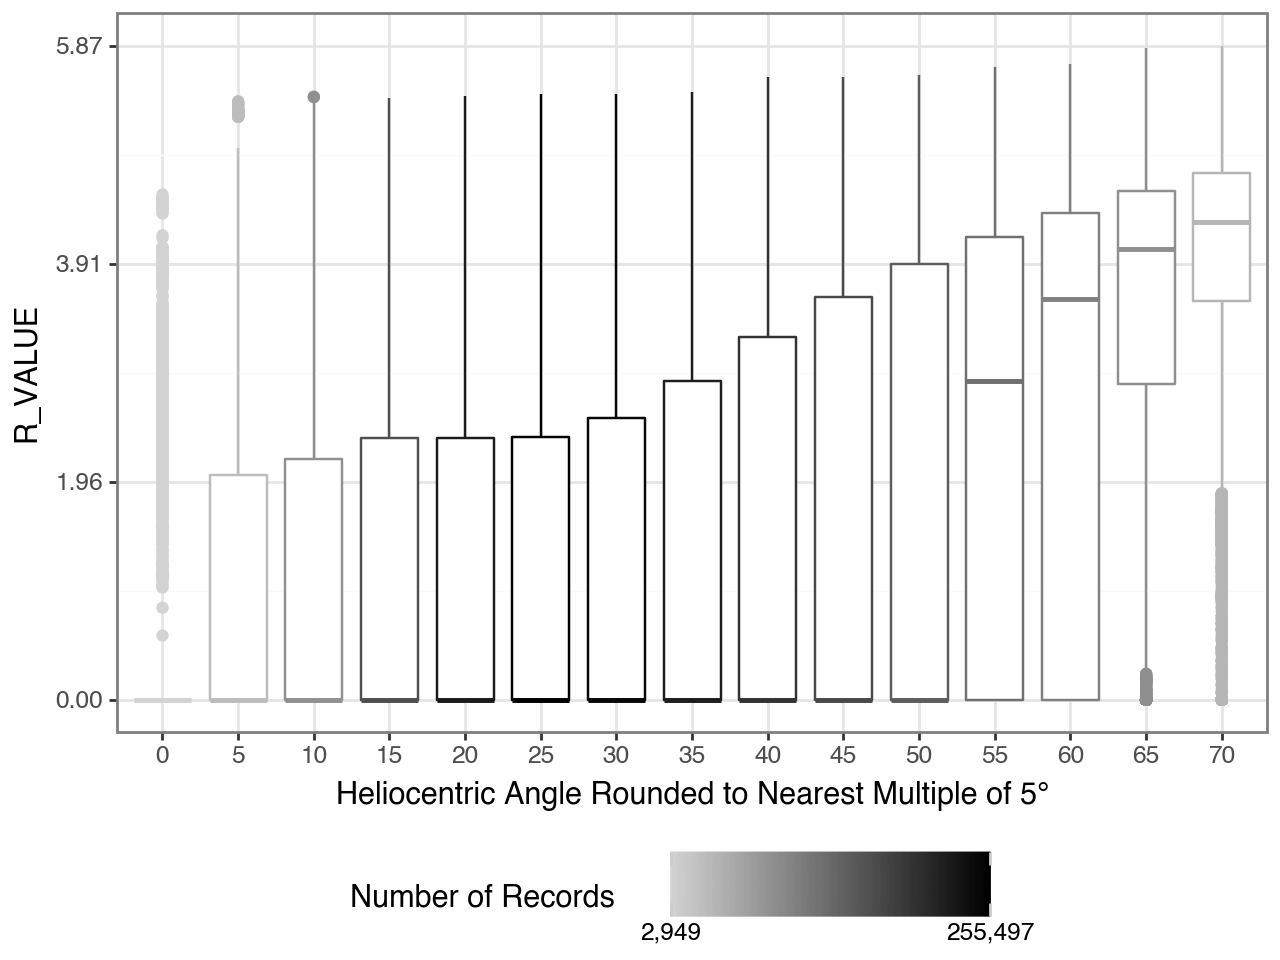

In [18]:
plot_param_cond_dists("R_VALUE")

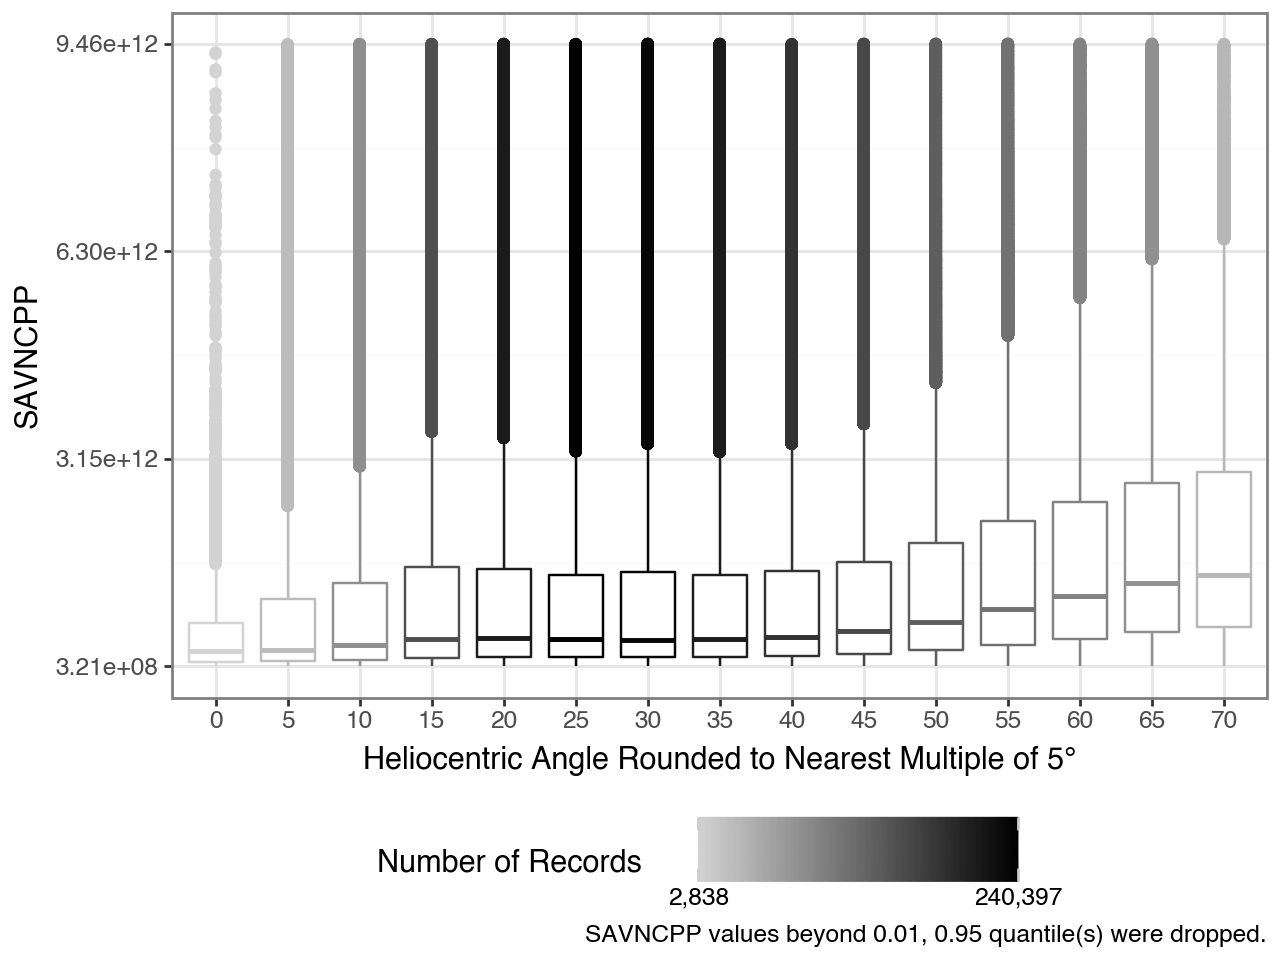

In [19]:
plot_param_cond_dists(
    "SAVNCPP", min_quantile_level=0.01, max_quantile_level=0.95
)

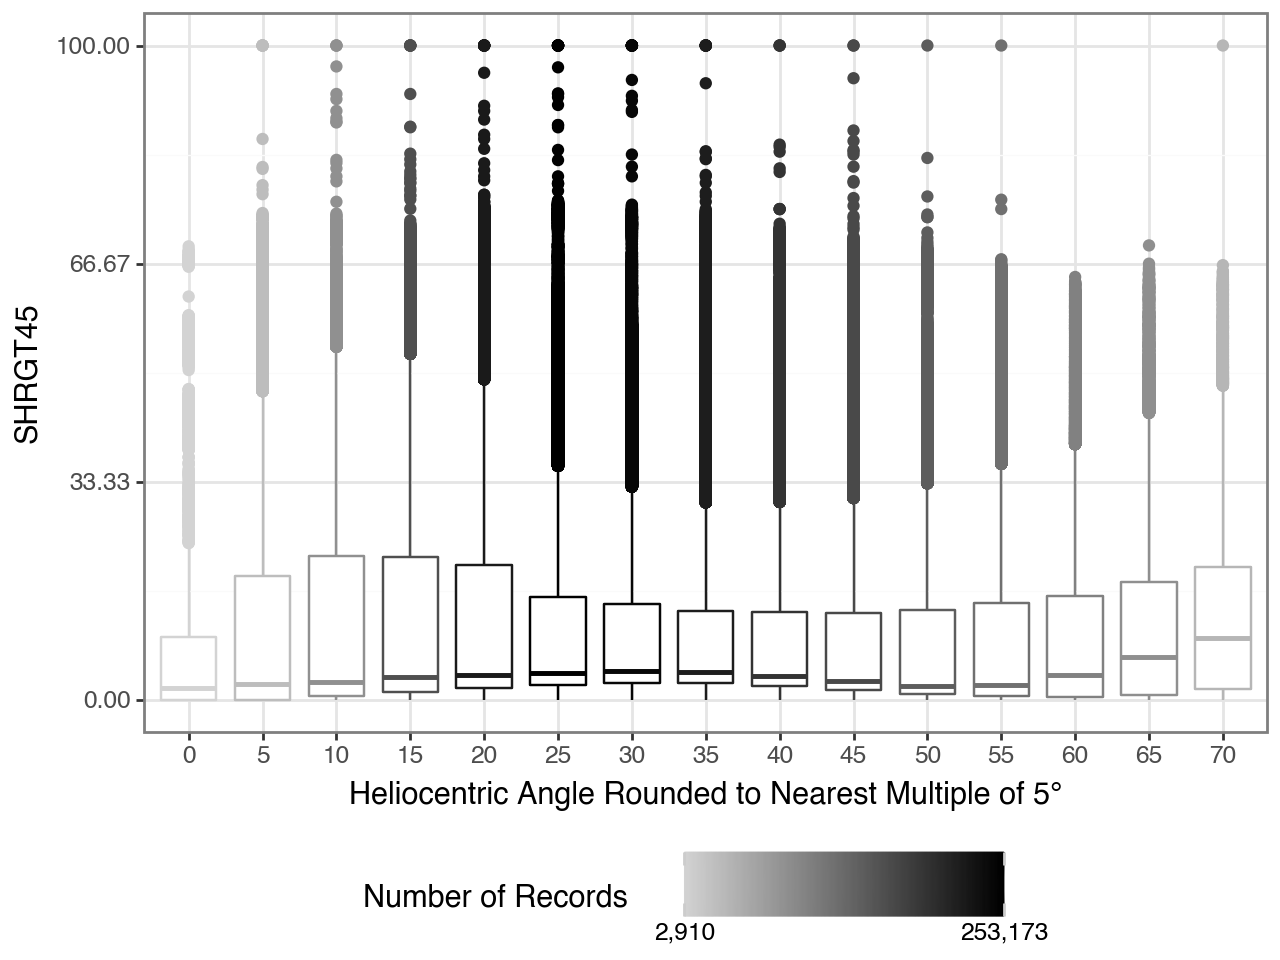

In [20]:
plot_param_cond_dists("SHRGT45")

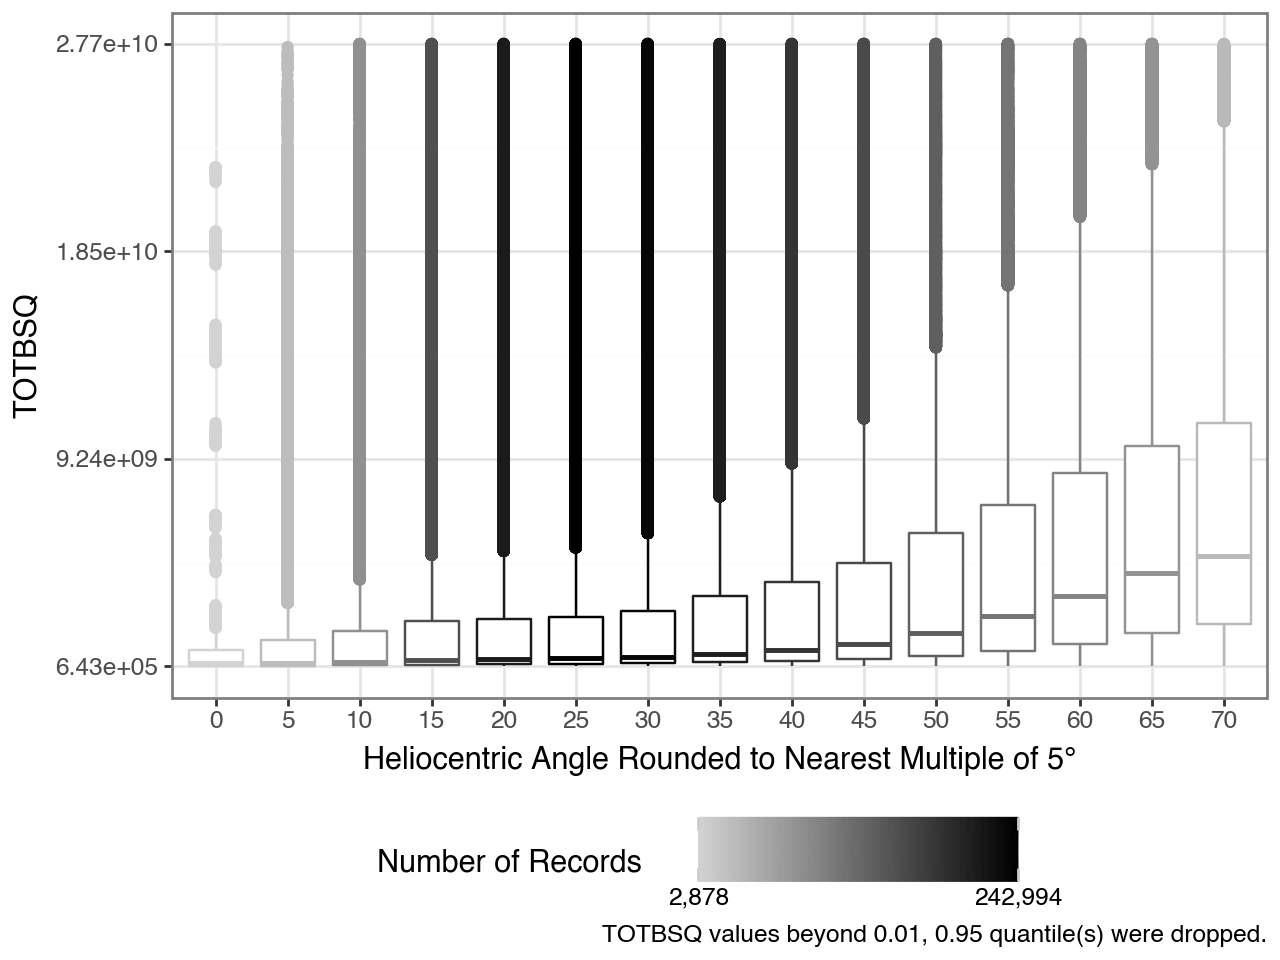

In [21]:
plot_param_cond_dists(
    "TOTBSQ", min_quantile_level=0.01, max_quantile_level=0.95
)

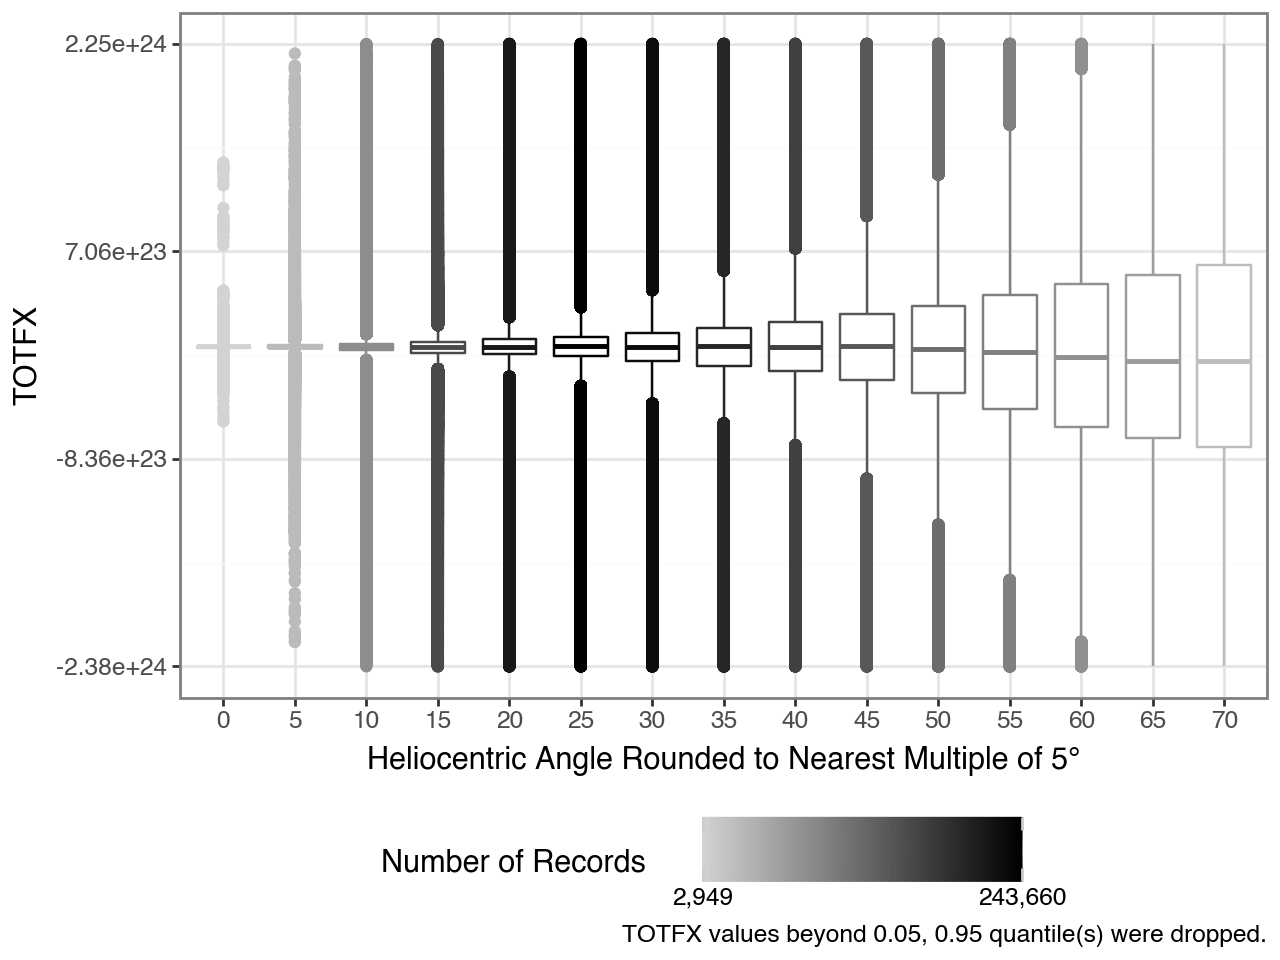

In [22]:
plot_param_cond_dists("TOTFX", min_quantile_level=0.05, max_quantile_level=0.95)

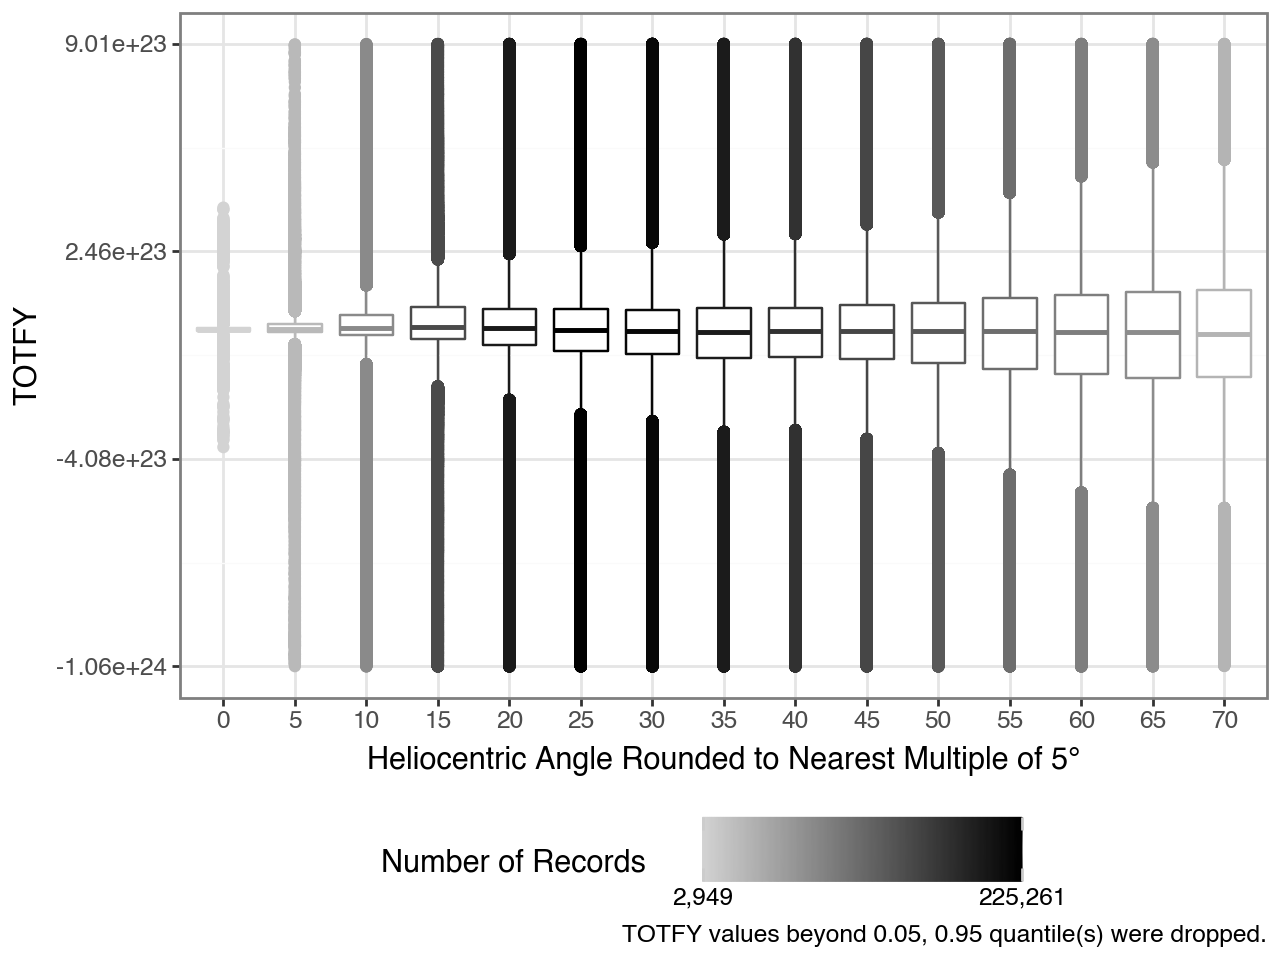

In [23]:
plot_param_cond_dists("TOTFY", min_quantile_level=0.05, max_quantile_level=0.95)

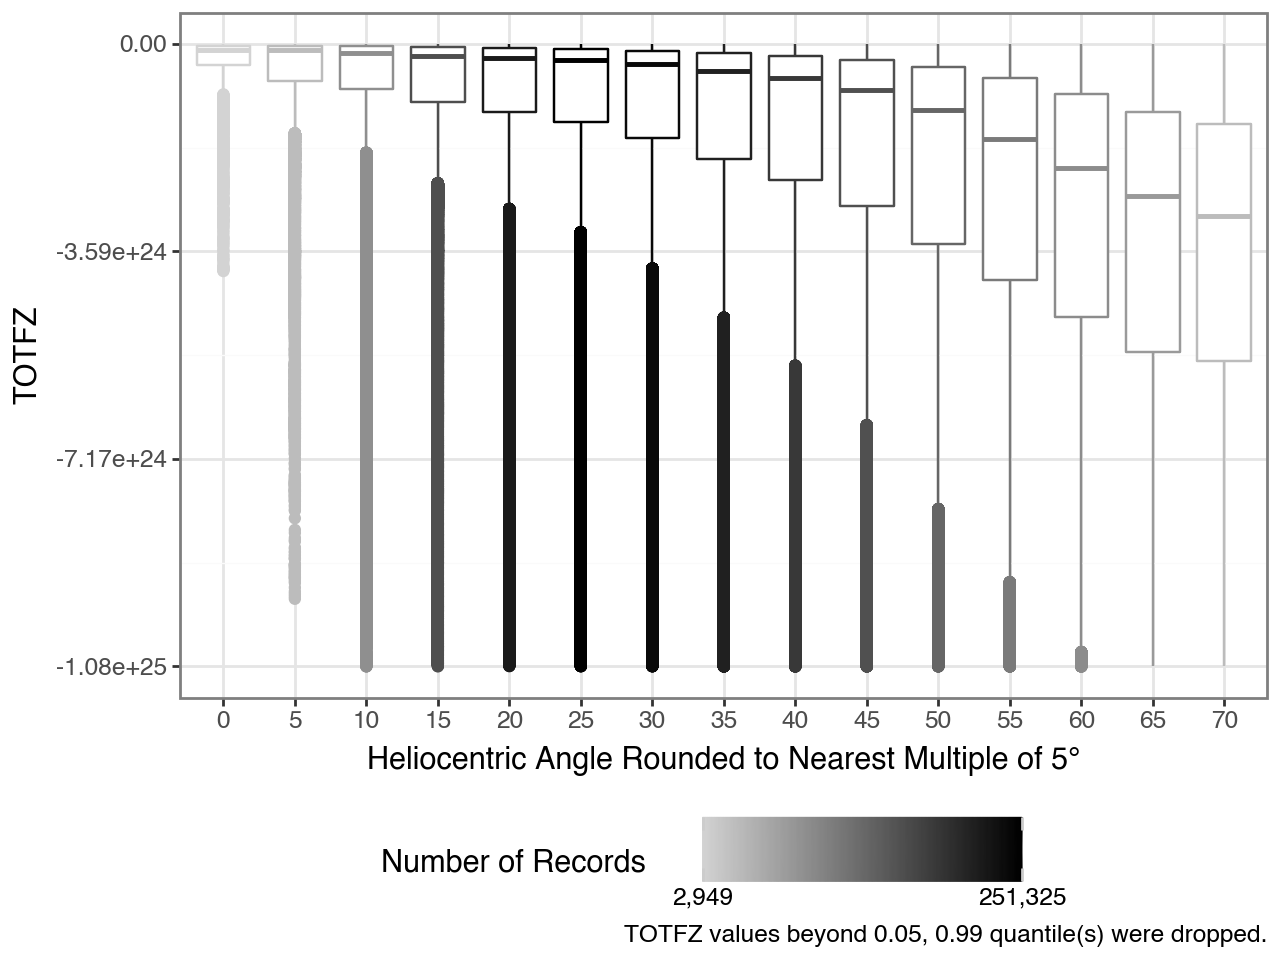

In [24]:
plot_param_cond_dists("TOTFZ", min_quantile_level=0.05, max_quantile_level=0.99)

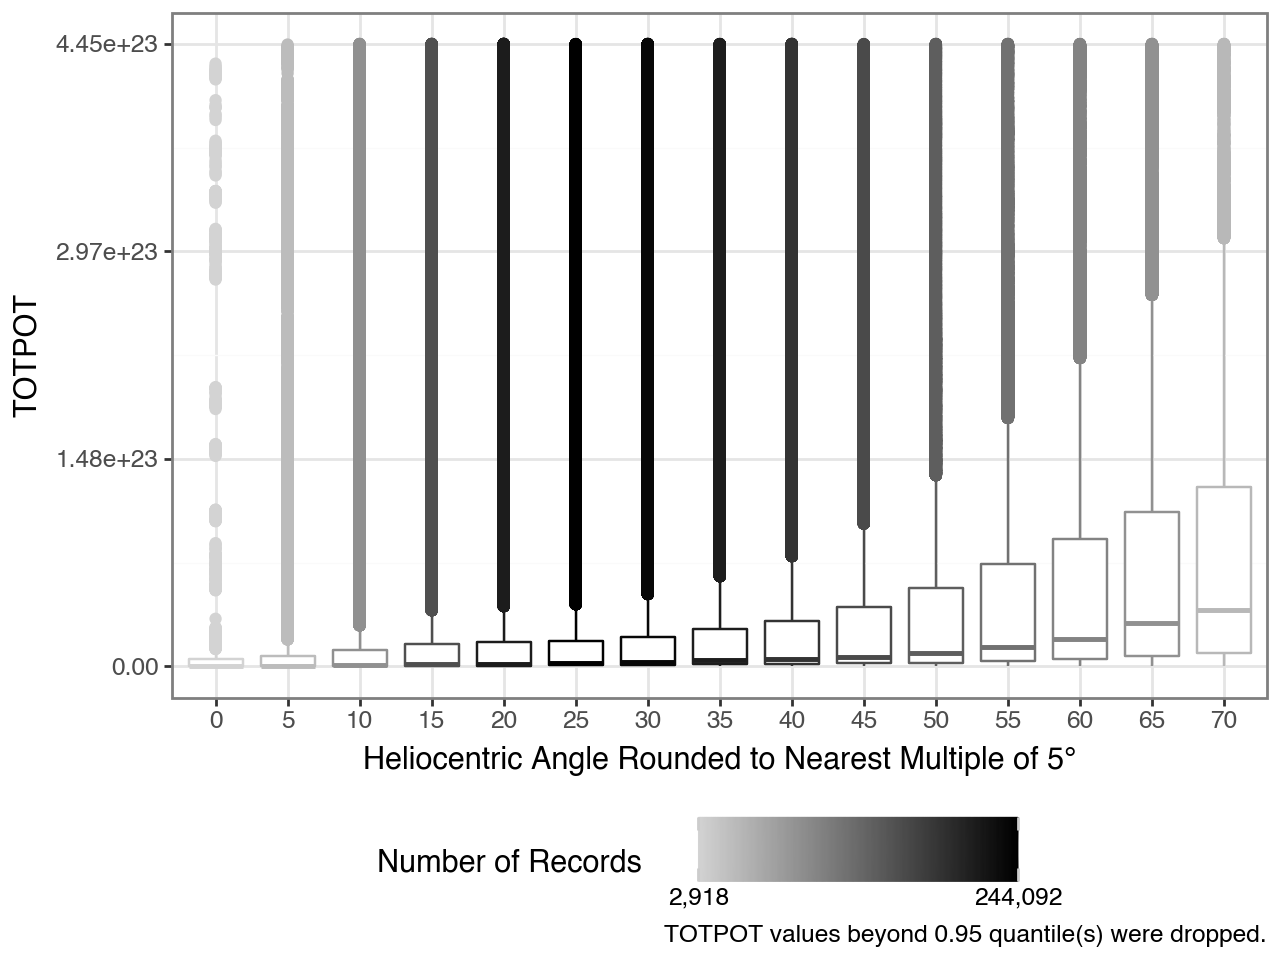

In [25]:
plot_param_cond_dists("TOTPOT", max_quantile_level=0.95)

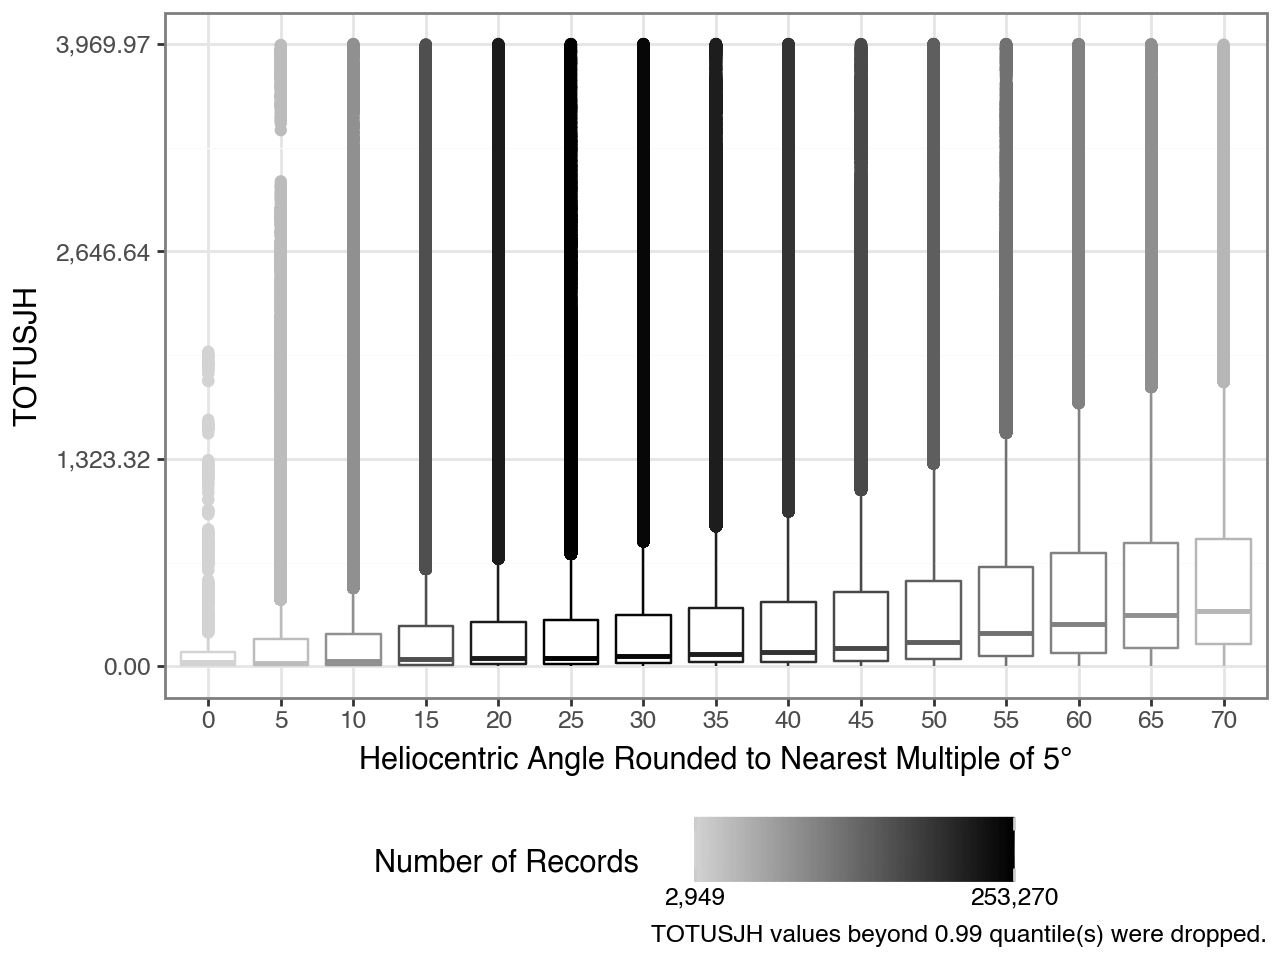

In [26]:
plot_param_cond_dists("TOTUSJH", max_quantile_level=0.99)

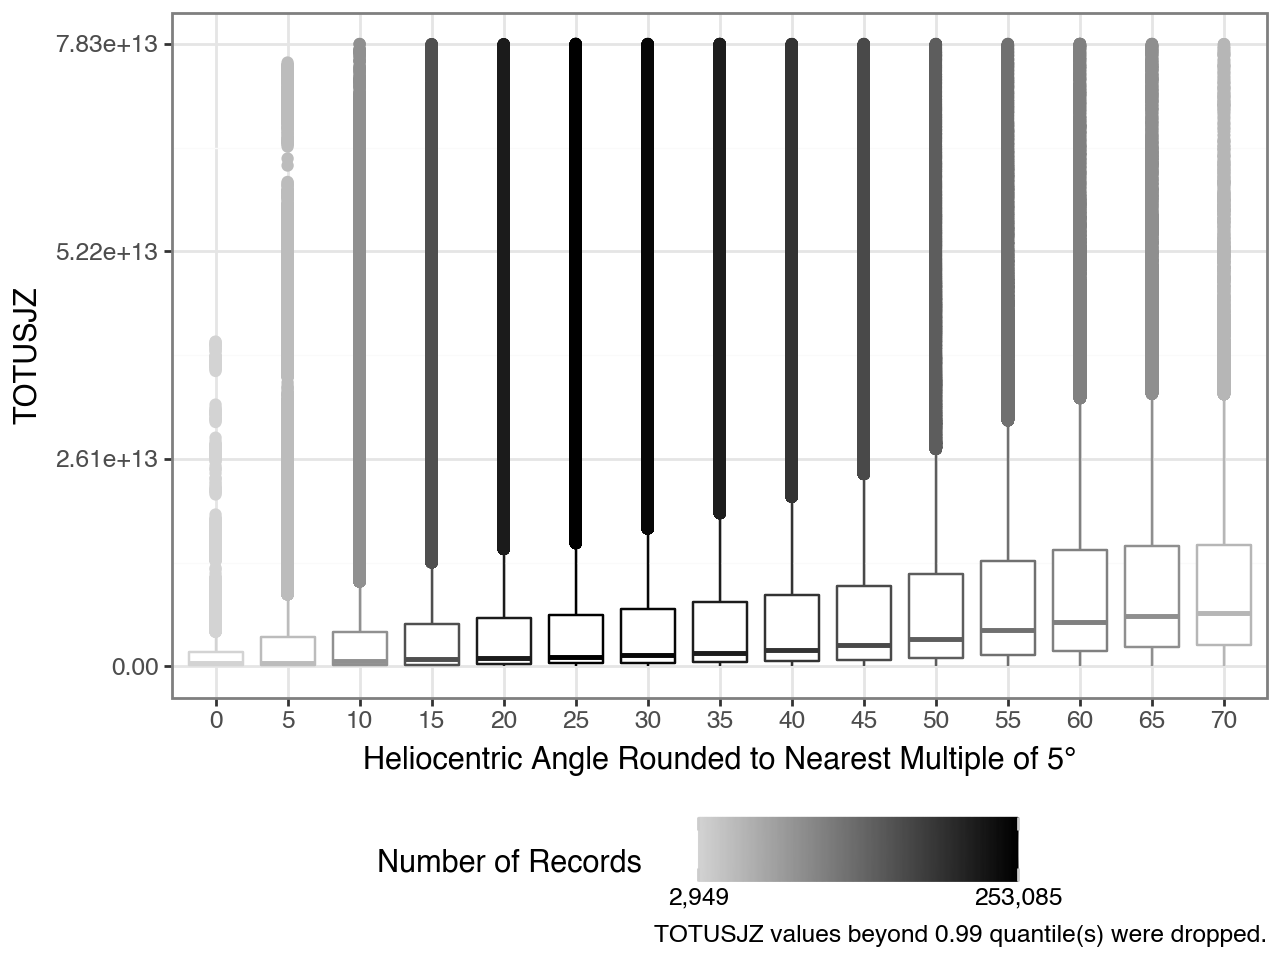

In [27]:
plot_param_cond_dists("TOTUSJZ", max_quantile_level=0.99)

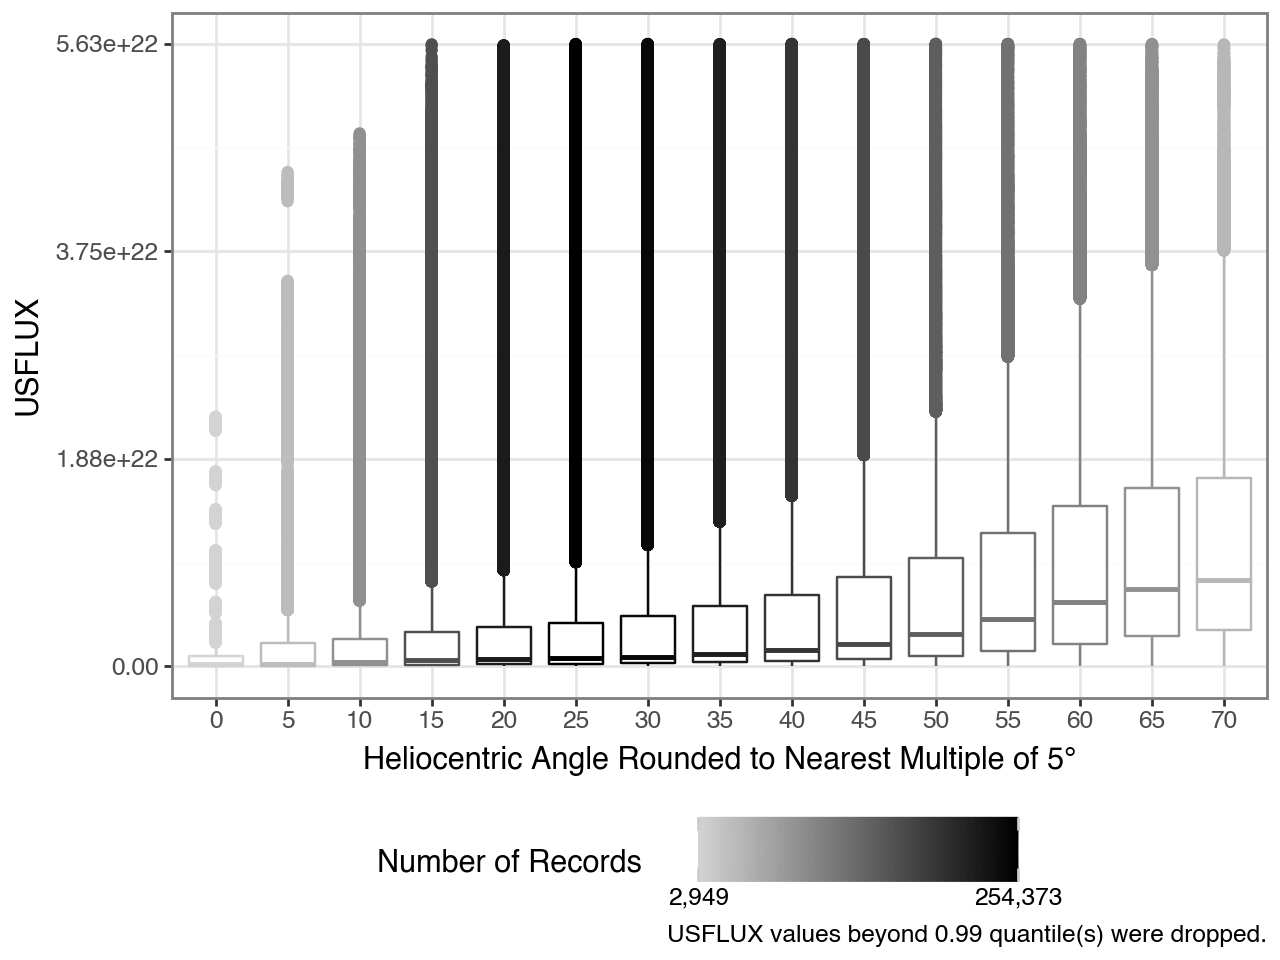

In [28]:
plot_param_cond_dists("USFLUX", min_quantile_level=0.0, max_quantile_level=0.99)